# **Customer Service Triage**

The workflow in this lesson handles four categories of customer support messages. FAQ questions go to an LLM-powered answer node. Billing questions go to a specialist response node. Escalation triggers go to a holding message that flags the request for human review. Anything the classifier is not confident about, or any message that does not match a known category, goes to the fallback node.

## **Step 1: Design the State**

The state schema for this workflow is intentionally narrow. Routing is the focus, so we carry only the fields, the routing logic, and the handlers need.

In [1]:
from typing import TypedDict

class SupportState(TypedDict):
    # Input — provided at invocation, never modified
    user_message: str

    # Control — written by the classifier node
    intent: str
    confidence: str

    # Output — written by whichever handler runs
    response: str

## **Step 2: Setting up the Nodes**

### **The classifier node**

The classifier scores the user message against keyword lists for each known intent. The intent with the highest keyword match score becomes the label. The confidence level depends on how many keywords matched.

In [2]:
def classify_intent(state: SupportState) -> dict:
    text = state["user_message"].lower()

    intent_keywords = {
        "faq":        ["how", "what", "when", "does", "can", "feature", "work", "explain"],
        "billing":    ["invoice", "charge", "payment", "refund", "subscription", "price", "cost"],
        "escalation": ["complaint", "unacceptable", "manager", "legal", "terrible", "lawsuit"],
    }

    scores = {
        intent: sum(1 for kw in keywords if kw in text)
        for intent, keywords in intent_keywords.items()
    }

    best_intent = max(scores, key=scores.get)
    best_score = scores[best_intent]

    if best_score == 0:
        return {"intent": "fallback", "confidence": "low"}

    confidence = "high" if best_score >= 2 else "low"
    return {"intent": best_intent, "confidence": confidence}

### **The handler nodes**

Each of the four handlers writes to response. Only the FAQ handler uses a large language model. The others use deterministic responses, which is appropriate because their purpose is not to generate content but to acknowledge, inform, or gather more information.

The FAQ handler calls model for general product and feature questions:

In [3]:
from langchain_core.runnables import RunnableConfig

def handle_faq(state: SupportState, config: RunnableConfig) -> dict:
    model = config["configurable"]["model"]
    prompt = config["configurable"]["support_prompt"]
    
    chain = prompt | model
    
    # Invocation
    response = chain.invoke({
        "user_message": state['user_message'],
    })

    return {"response": response.content}

The billing handler returns a structured response that guides the user without attempting to answer billing questions directly:

In [4]:
def handle_billing(state: SupportState) -> dict:
    return {
        "response": (
            "For billing and payment questions, our team is ready to help. "
            "Please share your account email and the invoice or transaction reference, "
            "and we will look into this within one business day."
        )
    }

The escalation handler flags the request for review without engaging on the substance:

In [5]:
def handle_escalation(state: SupportState) -> dict:
    return {
        "response": (
            "We take your concern seriously and want to make sure it receives proper attention. "
            "A senior team member will review your message and follow up within 24 hours."
        )
    }

The fallback handler is the safety net for low-confidence or unrecognized messages:

In [6]:
def handle_fallback(state: SupportState) -> dict:
    return {
        "response": (
            "I want to make sure I direct your question to the right place. "
            "Could you describe what you need help with in a bit more detail?"
        )
    }

## **Step 3: Building the Workflow**

### **The routing function**

The routing function reads both `confidence` and `intent` from state. Confidence is checked first. If it is low, we route to fallback regardless of the intent label. If confidence is high, we use the mapping dictionary to translate the label to a node name.

In [7]:
from typing import Literal

def route_by_intent(
    state: SupportState,
) -> Literal["handle_faq", "handle_billing", "handle_escalation", "handle_fallback"]:
    if state["confidence"] == "low":
        return "handle_fallback"

    route_map = {
        "faq":        "handle_faq",
        "billing":    "handle_billing",
        "escalation": "handle_escalation",
        "fallback":   "handle_fallback",
    }
    return route_map.get(state["intent"], "handle_fallback")

### **Graph assembly**

With five nodes and one routing function, the graph wiring follows a familiar pattern.

In [8]:
from langgraph.graph import END, START, StateGraph

def build_graph():
    graph = StateGraph(SupportState)
    graph.add_node("classify_intent", classify_intent)
    graph.add_node("handle_faq", handle_faq)
    graph.add_node("handle_billing", handle_billing)
    graph.add_node("handle_escalation", handle_escalation)
    graph.add_node("handle_fallback", handle_fallback)

    graph.add_edge(START, "classify_intent")
    graph.add_conditional_edges("classify_intent", route_by_intent)
    graph.add_edge("handle_faq", END)
    graph.add_edge("handle_billing", END)
    graph.add_edge("handle_escalation", END)
    graph.add_edge("handle_fallback", END)

    return graph.compile()

In [9]:
workflow = build_graph()

## **Step 4: Visualizing the Graph**

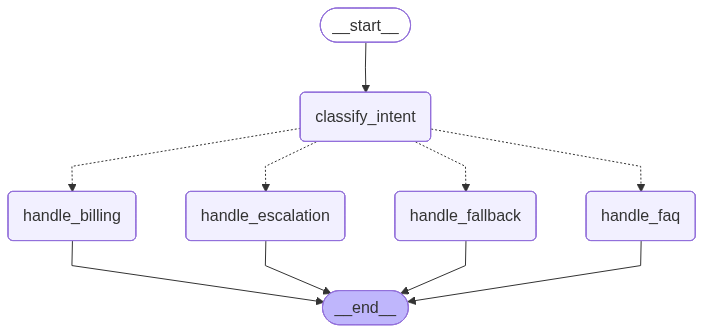

In [10]:
# Visualize the Graph
from IPython.display import Image, display

display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))

## **Step 5: Running the Workflow**

### **Initializing the Prompts**

In [11]:
from langchain_core.prompts import ChatPromptTemplate

support_prompt = ChatPromptTemplate(
    messages=[
        ("system", "You are a helpful customer support assistant."),
        ("human", 
         "Answer the following question clearly in 3-4 sentences.\n\n"
         "Customer question: {user_message}"
        ), 
    ]
)

### **Initializing the Chat Models**

In [12]:
from langchain_groq import ChatGroq

with open("keys/.groq_api_key.txt") as f:
    GROQ_API_KEY = f.read()

groq_chat_model = ChatGroq(
    api_key=GROQ_API_KEY, 
    model="openai/gpt-oss-120b", 
    temperature=1
)

groq_chat_model.invoke("hi").content

'Hello! 👋 How can I assist you today?'

### **Defining the Test Cases**

In [13]:
cases = [
    {
        "message": "How does the export feature work?",
        "expected_intent": "faq",
        "expected_confidence": "high",
        "expected_handler": "handle_faq",
    },
    {
        "message": "I was charged twice for my subscription this month.",
        "expected_intent": "billing",
        "expected_confidence": "high",
        "expected_handler": "handle_billing",
    },
    {
        "message": "This is completely unacceptable. I want to speak to a manager.",
        "expected_intent": "escalation",
        "expected_confidence": "high",
        "expected_handler": "handle_escalation",
    },
    {
        "message": "I need help.",
        "expected_intent": "fallback",
        "expected_confidence": "low",
        "expected_handler": "handle_fallback",
    },
    {
        "message": "What is the refund policy for annual plans?",
        "expected_intent": "billing",
        "expected_confidence": "high",
        "expected_handler": "handle_billing",
    },    
]

### **Invoking the Workflow**

In [15]:
print("=== Conditional routing patterns ===\n")
for case in cases:
    result = workflow.invoke({
        "user_message": case["message"],
        "intent": "",
        "confidence": "",
        "response": "",
    }, config={
        "configurable": {
            "model": groq_chat_model,
            "support_prompt": support_prompt
        }
    })
    print(f"Message   : {case["message"]}")
    print(f"Intent    : {result['intent']}")
    print(f"Confidence: {result['confidence']}")
    print(f"Response  : {result['response'][:120]}")
    print()

=== Conditional routing patterns ===

Message   : How does the export feature work?
Intent    : faq
Confidence: high
Response  : The export feature lets you download the data you’re working with in a common file format such as CSV, Excel, or PDF. Fi

Message   : I was charged twice for my subscription this month.
Intent    : billing
Confidence: high
Response  : For billing and payment questions, our team is ready to help. Please share your account email and the invoice or transac

Message   : This is completely unacceptable. I want to speak to a manager.
Intent    : escalation
Confidence: high
Response  : We take your concern seriously and want to make sure it receives proper attention. A senior team member will review your

Message   : I need help.
Intent    : fallback
Confidence: low
Response  : I want to make sure I direct your question to the right place. Could you describe what you need help with in a bit more 

Message   : What is the refund policy for annual plans?
Intent    : f

## **Extending routes safely**
Adding a new route to this pattern is a three-step operation. The steps are small, and each one is localized to a specific part of the code.

1. Add keywords for the new intent in the classifier.
2. Add the new node name to the routing function.
3. Register the new node and connect it to END in the graph builder. The existing code for all other nodes and edges is untouched.